In [1]:
import pandas as pd
from sqlalchemy import create_engine
from urllib.parse import quote
from matplotlib import pyplot as plt
import seaborn as sns

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


In [2]:
# параметры подключения
username = "student"
password = "123456sql@"
host = "rc1b-cpsjckr2wfkuk61s.mdb.yandexcloud.net"
port = "6432"
database = "Northwind"

# Кодируем пароль
encoded_password = quote(password)
print(encoded_password)

# Формируем строку подключения
connection_string = f'postgresql+psycopg2://{username}:{encoded_password}@{host}:{port}/{database}'
engine = create_engine(connection_string)

123456sql%40


#### Подготавливаем датасет

In [3]:
#sql запрос
query = """
select date(date_created) as date_created,
sum(quantity * price) as gmv_created,
count(distinct o.order_id) as orders_created
from sandbox.orders o join  sandbox.order_details od on o.order_id = od.order_id 
group by date(date_created)
"""
df = pd.read_sql_query(query, engine)
df.head(3)

,date_created,gmv_created,orders_created
0,2017-01-05,396.90,32
1,2017-01-06,916.38,4
2,2017-01-07,1351.90,4


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 557 entries, 0 to 556
Data columns (total 3 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   date_created    557 non-null    object 
 1   gmv_created     557 non-null    float64
 2   orders_created  557 non-null    int64  
dtypes: float64(1), int64(1), object(1)
memory usage: 13.2+ KB


In [5]:
#cначала переводим дату в формат datetime, а затем извлекаем из даты день и месяц
df['date_created'] = df.date_created.astype('datetime64[ns]')
df['month_created'] = df.date_created.dt.to_period('M').dt.to_timestamp()
df['week_created'] = df.date_created.dt.to_period('W').dt.to_timestamp()
df.head(3)

,date_created,gmv_created,orders_created,month_created,week_created
0,2017-01-05,396.90,32,2017-01-01,2017-01-02
1,2017-01-06,916.38,4,2017-01-01,2017-01-02
2,2017-01-07,1351.90,4,2017-01-01,2017-01-02


In [6]:
#cчитаем GMV и кол-во заказов по месяцам
df_monthly = df.groupby('month_created', as_index = False).agg({'gmv_created':'sum', 'orders_created':'sum'})
df_monthly.head(3)

,month_created,gmv_created,orders_created
0,2017-01-01,112080.31,750
1,2017-02-01,227549.44,1606
2,2017-03-01,354646.41,2524


In [7]:
#считаем AOV
df_monthly['aov_created'] = df_monthly.gmv_created/df_monthly.orders_created
df_monthly.tail(3)

,month_created,gmv_created,orders_created,aov_created
16,2018-05-01,978876.09,6747,145.083161
17,2018-06-01,859495.57,6105,140.785515
18,2018-07-01,333396.68,2318,143.829456


#### Считаем прирост месяца к месяцу

In [8]:
#прирост месяц к месяцу
(df_monthly.tail(3).T[1:][17]/df_monthly.tail(3).T[1:][16]-1)*100

gmv_created      -12.195672
orders_created     -9.51534
aov_created       -2.962195
dtype: object

#### Смотрим метрики в динамике

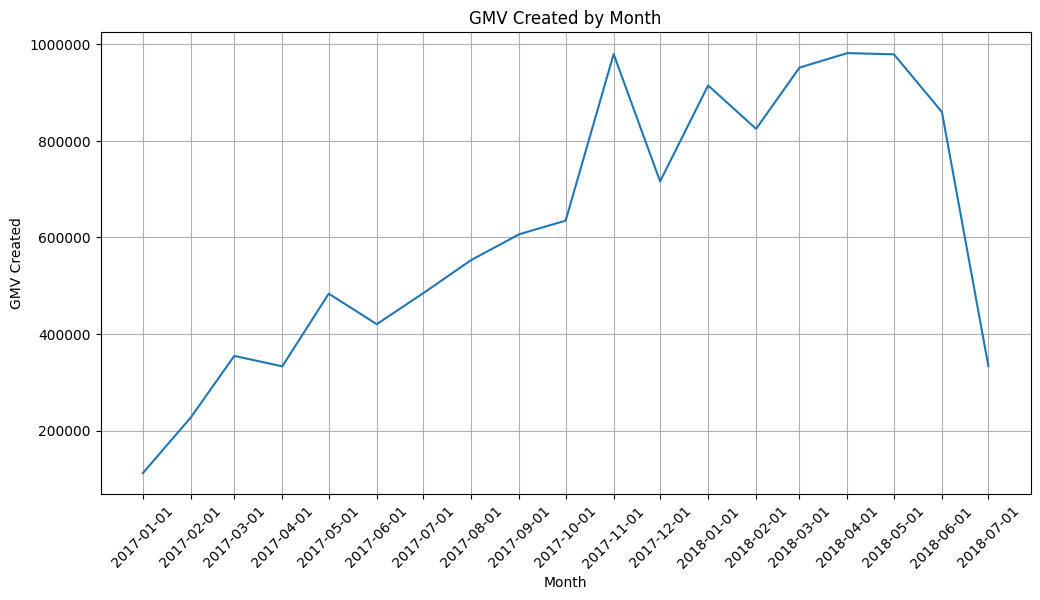

In [10]:
plt.figure(figsize=(12, 6)) #настройка размера чарта
plt.plot(
        df_monthly.month_created, #ось Х
        df_monthly.gmv_created #ось Y
        )
plt.xticks(
           df_monthly.month_created.unique(), #отображаем все месяца
           rotation=45)  #Поворот меток на 45% для лучшей читаемости
plt.ylabel('GMV Created') #название оси Y
plt.title('GMV Created by Month') #название оси X
plt.xlabel('Month') #название графика
plt.grid() #название чарта
plt.ticklabel_format(axis='y', style='plain') #отображение метрики GMV не в научной нотации
plt.show() #показ графика

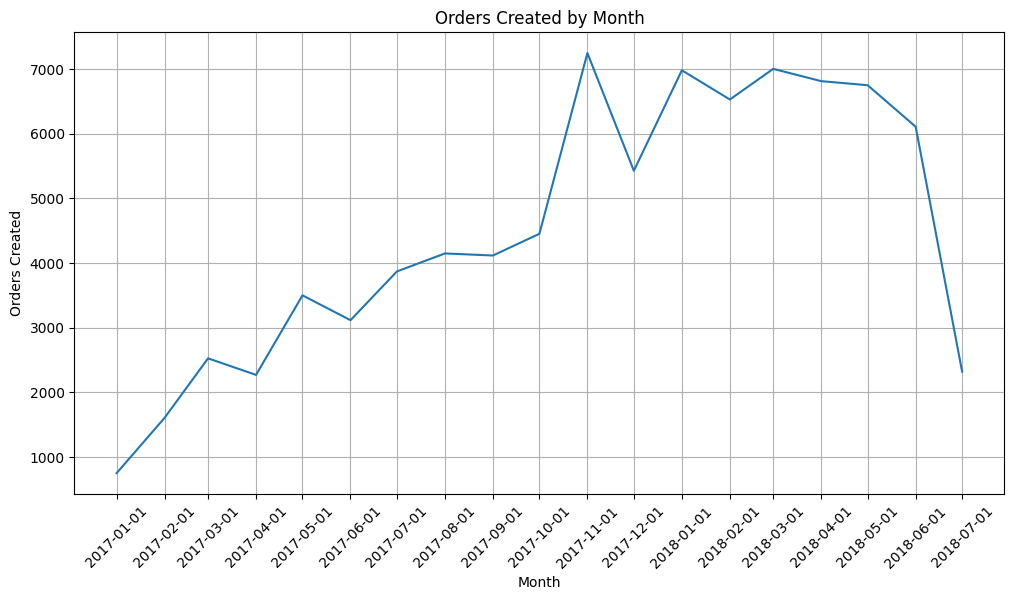

In [11]:
plt.figure(figsize=(12, 6))
plt.plot(
        df_monthly.month_created,
        df_monthly.orders_created
        )
plt.xticks(
            df_monthly.month_created.unique(), 
           rotation=45)  #Поворот меток на 45% для лучшей читаемости
plt.ylabel('Orders Created')
plt.title('Orders Created by Month')
plt.xlabel('Month')
plt.grid()
plt.show()

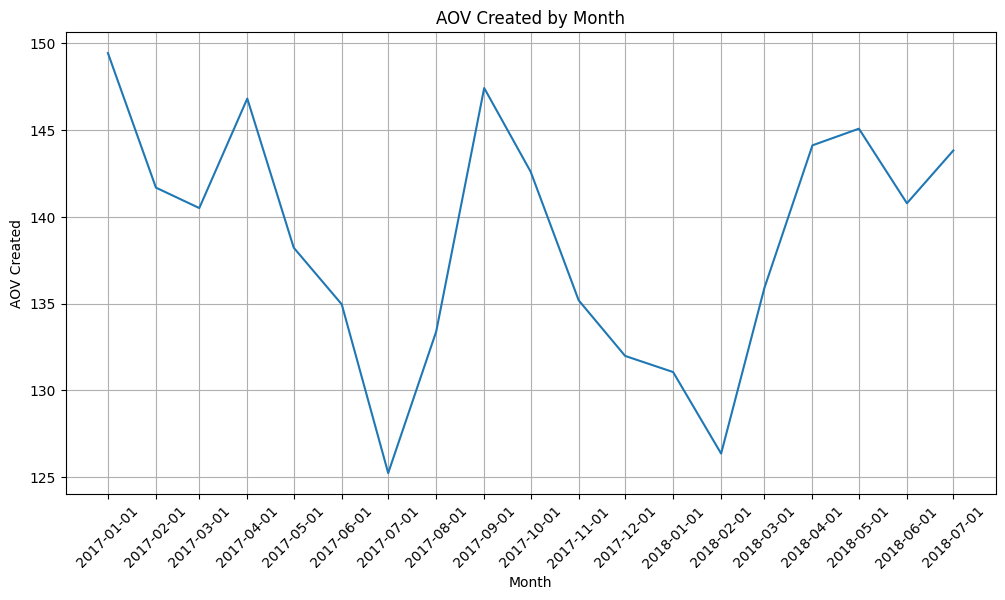

In [12]:
plt.figure(figsize=(12, 6))
plt.plot(
        df_monthly.month_created,
        df_monthly.aov_created
        )
plt.xticks(
           df_monthly.month_created.unique(), 
           rotation=45)  #Поворот меток на 45% для лучшей читаемости
plt.ylabel('AOV Created')
plt.title('AOV Created by Month')
plt.xlabel('Month')
plt.grid()
plt.show()

#### Пример с применением библиотеки seaborn

/opt/anaconda3/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


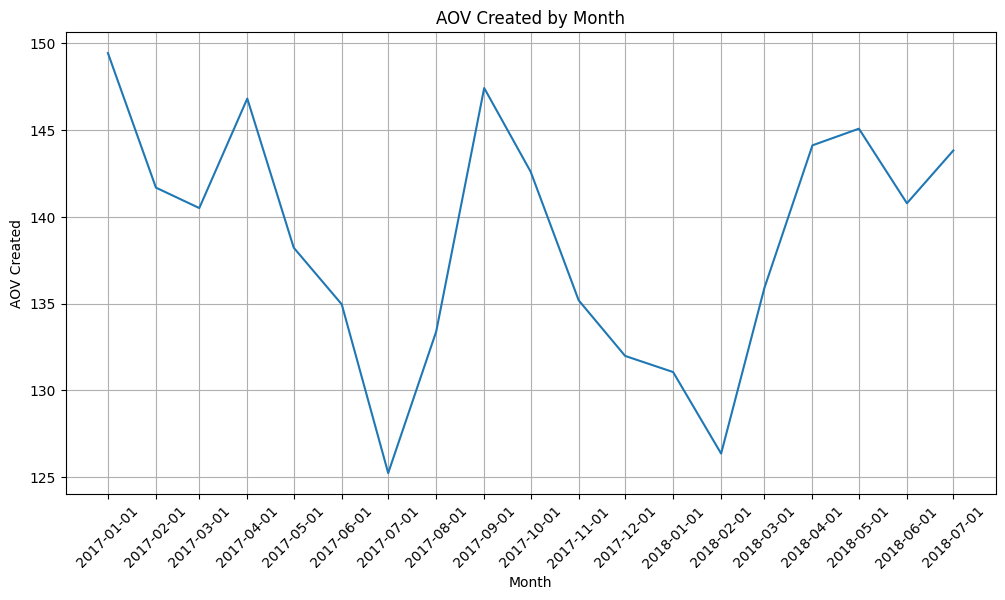

In [14]:
plt.figure(figsize=(12, 6))
#plt.plot(df_monthly.month_created, df_monthly.aov)
sns.lineplot(data=df_monthly, x='month_created', y='aov_created') #построение графика с помощью библиотеки seaborn
plt.xticks(
            df_monthly.month_created.unique(), 
           rotation=45)  #Поворот меток на 45% для лучшей читаемости
plt.ylabel('AOV Created')
plt.title('AOV Created by Month')
plt.xlabel('Month')
plt.grid()
plt.show()